In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Put YOUR full path here
dataset_path = Path('C:/Users/rayan/Downloads/MLPC2026_dataset_development')

npz_files = list((dataset_path / 'audio_features').glob('*.npz'))
print(f"Found {len(npz_files)} files")

data = np.load(npz_files[0], allow_pickle=True)
class_names = data['class_names']
print("Classes:", class_names)

Found 3656 files
Classes: ['bell_ringing' 'coffee_machine' 'cutlery_dishes' 'door_open_close'
 'footsteps' 'keyboard_typing' 'keychain' 'light_switch' 'microwave'
 'phone_ringing' 'running_water' 'toilet_flushing' 'vacuum_cleaner'
 'wardrobe_drawer_open_close' 'window_open_close']


Found 3656 files

Question 2a: Annotator Agreement Results

Overall Annotator Agreement: 95.33%
Number of files analyzed: 3031

Class-wise Annotator Agreement:
---------------------------------------------
bell_ringing                   98.39%
coffee_machine                 98.63%
cutlery_dishes                 93.04%
door_open_close                91.61%
footsteps                      84.82%
keyboard_typing                95.38%
keychain                       94.33%
light_switch                   97.36%
microwave                      97.10%
phone_ringing                  95.44%
running_water                  95.30%
toilet_flushing                97.38%
vacuum_cleaner                 98.48%
wardrobe_drawer_open_close     95.43%
window_open_close              97.21%

Generating bar chart...


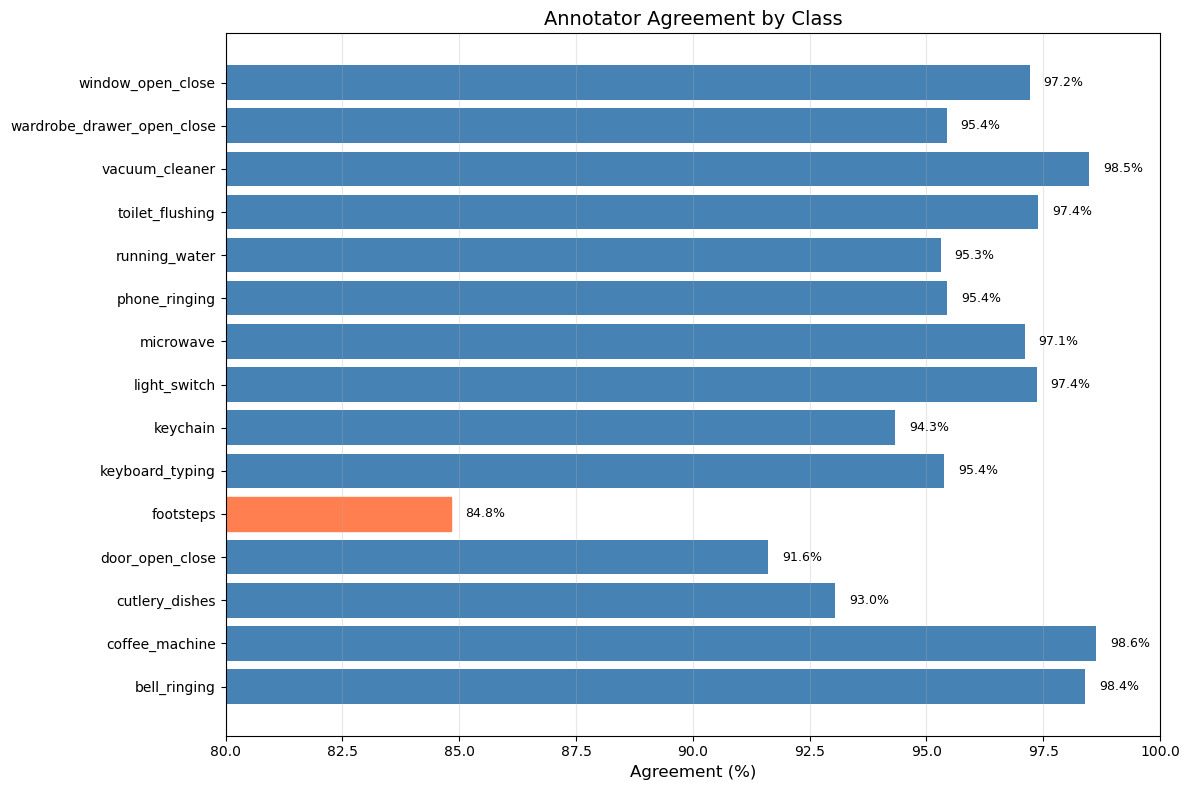


Question 2a Complete!


In [2]:
# Question 2a - Complete Code with Bar Chart
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your dataset
dataset_path = Path('C:/Users/rayan/Downloads/MLPC2026_dataset_development')
npz_files = list((dataset_path / 'audio_features').glob('*.npz'))
print(f"Found {len(npz_files)} files")
print()

# Store results
all_agreements = []
class_agreement_all = []

for npz_path in npz_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        ann = data['annotations']
        class_names = data['class_names']
        
        # Skip if less than 2 annotators
        if ann.shape[2] < 2:
            continue
        
        agreement_count = 0
        class_agreement = np.zeros(ann.shape[1])
        total = ann.shape[0] * ann.shape[1]
        
        for t in range(ann.shape[0]):
            for c in range(ann.shape[1]):
                labels = ann[t, c, :]
                if np.all(labels == labels[0]):
                    agreement_count += 1
                    class_agreement[c] += 1
        
        class_agreement = class_agreement / ann.shape[0]
        class_agreement_all.append(class_agreement)
        all_agreements.append(agreement_count / total)
        
    except Exception as e:
        continue

# Calculate final results
overall_agreement = np.mean(all_agreements) * 100
avg_class_agreement = np.mean(class_agreement_all, axis=0) * 100

# Print results
print("=" * 60)
print("Question 2a: Annotator Agreement Results")
print("=" * 60)
print()
print(f"Overall Annotator Agreement: {overall_agreement:.2f}%")
print(f"Number of files analyzed: {len(all_agreements)}")
print()
print("Class-wise Annotator Agreement:")
print("-" * 45)
for i, class_name in enumerate(class_names):
    print(f"{class_name:30} {avg_class_agreement[i]:.2f}%")
print()

# Create bar chart
print("Generating bar chart...")
plt.figure(figsize=(12, 8))

# Create horizontal bar chart
bars = plt.barh(class_names, avg_class_agreement, color='steelblue')

# Highlight the lowest agreement class
min_idx = np.argmin(avg_class_agreement)
bars[min_idx].set_color('coral')

# Add labels and title
plt.xlabel('Agreement (%)', fontsize=12)
plt.title('Annotator Agreement by Class', fontsize=14)
plt.xlim(80, 100)

# Add value labels at the end of each bar
for bar, value in zip(bars, avg_class_agreement):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{value:.1f}%', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Question 2a Complete!")
print("=" * 60)

In [3]:
#---------------------------------------2b-----------------------------------
total_segments = 0
total_sound_segments = 0
all_sound_percentages = []

# Store binary labels for later use in 2c (optional)
all_binary_labels = []

for npz_path in npz_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        ann = data['annotations']

        # Skip if less than 2 annotators
        if ann.shape[2] < 2:
            continue
        
        # Convert to binary using majority voting (2 out of 3)
        binary = np.zeros((ann.shape[0], ann.shape[1]))
        for t in range(ann.shape[0]):
            for c in range(ann.shape[1]):
                if ann[t, c, :].sum() >= 2:
                    binary[t, c] = 1
        
        # Calculate sound presence (any class active)
        segments_with_sound = (binary.sum(axis=1) > 0).sum()
        total_segments_in_file = binary.shape[0]
        
        total_segments += total_segments_in_file
        total_sound_segments += segments_with_sound
        
        sound_percentage = (segments_with_sound / total_segments_in_file) * 100
        all_sound_percentages.append(sound_percentage)
        
        # Store for 2c (optional - only store first 100 files to save memory)
        if len(all_binary_labels) < 100:
            all_binary_labels.append({
                'binary': binary,
                'class_names': data['class_names'],
                'start_time': data['start_time'],
                'end_time': data['end_time']
            })
        
    except Exception as e:
        continue

# Calculate overall statistics
overall_sound_percentage = (total_sound_segments / total_segments) * 100
avg_sound_percentage = np.mean(all_sound_percentages)
std_sound_percentage = np.std(all_sound_percentages)

print(f"Total files analyzed: {len(all_sound_percentages)}")
print(f"Total time segments analyzed: {total_segments:,}")
print(f"Total segments containing sound: {total_sound_segments:,}")
print()
print(f"Overall percentage of time containing sound: {overall_sound_percentage:.2f}%")
print(f"Average percentage per file: {avg_sound_percentage:.2f}%")
print(f"Standard deviation across files: {std_sound_percentage:.2f}%")
print()
print("Method: Majority voting (2 out of 3 annotators)")
print("Binary label = 1 if at least 2 annotators marked ANY sound")

Total files analyzed: 3031
Total time segments analyzed: 139,259
Total segments containing sound: 76,413

Overall percentage of time containing sound: 54.87%
Average percentage per file: 54.55%
Standard deviation across files: 26.98%

Method: Majority voting (2 out of 3 annotators)
Binary label = 1 if at least 2 annotators marked ANY sound


In [4]:
# Question 2c - Complete Code (Files with ≥2 annotators only)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# Path to dataset
dataset_path = Path('C:/Users/rayan/Downloads/MLPC2026_dataset_development')
npz_files = list((dataset_path / 'audio_features').glob('*.npz'))
print(f"Total files in folder: {len(npz_files)}")
print()

# Filter files with at least 2 annotators
valid_files = []
class_names = None

for npz_path in npz_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        ann = data['annotations']
        if ann.shape[2] >= 2:
            valid_files.append(npz_path)
            if class_names is None:
                class_names = data['class_names']
    except Exception as e:
        continue

print(f"Files with at least 2 annotators: {len(valid_files)}")
print(f"Files excluded (less than 2 annotators): {len(npz_files) - len(valid_files)}")
print()

# ============================================================
# Part 1: Class Frequency
# ============================================================
print("=" * 60)
print("Question 2c Part 1: Class Frequency")
print("=" * 60)
print()

all_frequencies = []

for npz_path in valid_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        ann = data['annotations']
        
        # Convert to binary (majority voting - 2 out of 3)
        binary = np.zeros((ann.shape[0], ann.shape[1]))
        for t in range(ann.shape[0]):
            for c in range(ann.shape[1]):
                if ann[t, c, :].sum() >= 2:
                    binary[t, c] = 1
        
        # Frequency per class for this file
        freq = binary.mean(axis=0)
        all_frequencies.append(freq)
        
    except Exception as e:
        continue

avg_frequency = np.mean(all_frequencies, axis=0) * 100

freq_df = pd.DataFrame({
    'Class': class_names,
    'Frequency (%)': avg_frequency
}).sort_values('Frequency (%)', ascending=False)

print("CLASS FREQUENCY (percentage of time segments):")
print("-" * 50)
print(freq_df.to_string(index=False))
print()

# ============================================================
# Part 2: Class Duration
# ============================================================
print("=" * 60)
print("Question 2c Part 2: Class Duration")
print("=" * 60)
print()

class_durations = defaultdict(list)

for npz_path in valid_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        ann = data['annotations']
        
        # Convert to binary
        binary = np.zeros((ann.shape[0], ann.shape[1]))
        for t in range(ann.shape[0]):
            for c in range(ann.shape[1]):
                if ann[t, c, :].sum() >= 2:
                    binary[t, c] = 1
        
        # Get segment duration
        if 'start_time' in data and 'end_time' in data:
            segment_duration = (data['end_time'][0] - data['start_time'][0])
        else:
            segment_duration = 1.0
        
        # Calculate duration per class
        for c in range(ann.shape[1]):
            segments_with_class = binary[:, c].sum()
            if segments_with_class > 0:
                duration = segments_with_class * segment_duration
                class_durations[class_names[c]].append(duration)
                
    except Exception as e:
        continue

print("AVERAGE DURATION PER CLASS (seconds):")
print("-" * 45)
duration_data = []
for class_name in class_names:
    if len(class_durations[class_name]) > 0:
        avg_duration = np.mean(class_durations[class_name])
        duration_data.append((class_name, avg_duration))
        print(f"{class_name:30} {avg_duration:.2f} seconds")
print()

# ============================================================
# Part 3: Co-occurrence Patterns
# ============================================================
print("=" * 60)
print("Question 2c Part 3: Co-occurrence Patterns")
print("=" * 60)
print()

co_occurrence = np.zeros((len(class_names), len(class_names)))
file_count = 0

for npz_path in valid_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        ann = data['annotations']
        
        # Convert to binary
        binary = np.zeros((ann.shape[0], ann.shape[1]))
        for t in range(ann.shape[0]):
            for c in range(ann.shape[1]):
                if ann[t, c, :].sum() >= 2:
                    binary[t, c] = 1
        
        # Find co-occurring classes
        for t in range(binary.shape[0]):
            active_classes = np.where(binary[t] == 1)[0]
            for i in active_classes:
                for j in active_classes:
                    if i != j:
                        co_occurrence[i, j] += 1
        
        file_count += 1
        if file_count % 500 == 0:
            print(f"Processed {file_count} files...")
            
    except Exception as e:
        continue

print(f"\nTotal files processed: {file_count}")
print()

# Top co-occurring pairs
pairs = []
for i in range(len(class_names)):
    for j in range(i+1, len(class_names)):
        if co_occurrence[i, j] > 0:
            pairs.append((class_names[i], class_names[j], co_occurrence[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("TOP 10 CO-OCCURRING CLASS PAIRS:")
print("-" * 50)
for p in pairs_sorted[:10]:
    print(f"  {p[0]} + {p[1]}: {int(p[2])} segments")
print()

# ============================================================
# Summary
# ============================================================
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total files with ≥2 annotators: {len(valid_files)}")
print(f"Total class frequency sum: {avg_frequency.sum():.2f}%")
print(f"Number of classes: {len(class_names)}")
print("=" * 60)

Total files in folder: 3656

Files with at least 2 annotators: 3031
Files excluded (less than 2 annotators): 625

Question 2c Part 1: Class Frequency

CLASS FREQUENCY (percentage of time segments):
--------------------------------------------------
                     Class  Frequency (%)
             running_water      11.299097
                 footsteps       9.729513
           keyboard_typing       8.078791
                 microwave       6.028142
            vacuum_cleaner       5.952966
             phone_ringing       5.293398
            cutlery_dishes       4.117477
                  keychain       3.743895
            coffee_machine       2.911707
           toilet_flushing       2.654729
           door_open_close       1.957628
              bell_ringing       1.041073
wardrobe_drawer_open_close       0.973132
         window_open_close       0.718989
              light_switch       0.125954

Question 2c Part 2: Class Duration

AVERAGE DURATION PER CLASS (seconds):
----

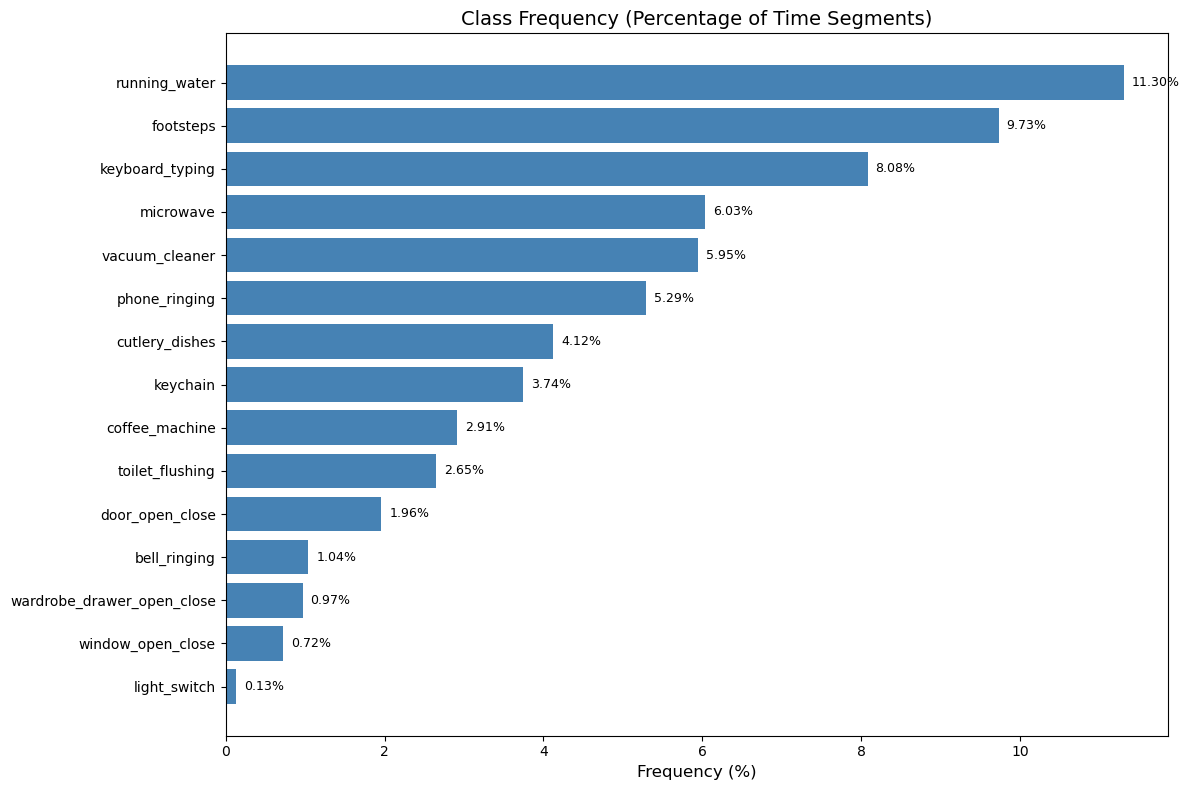

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your output
classes = ['running_water', 'footsteps', 'keyboard_typing', 'microwave', 
           'vacuum_cleaner', 'phone_ringing', 'cutlery_dishes', 'keychain',
           'coffee_machine', 'toilet_flushing', 'door_open_close', 
           'bell_ringing', 'wardrobe_drawer_open_close', 'window_open_close', 
           'light_switch']
frequencies = [11.30, 9.73, 8.08, 6.03, 5.95, 5.29, 4.12, 3.74, 2.91, 2.65, 
               1.96, 1.04, 0.97, 0.72, 0.13]

plt.figure(figsize=(12, 8))
bars = plt.barh(classes, frequencies, color='steelblue')
plt.xlabel('Frequency (%)', fontsize=12)
plt.title('Class Frequency (Percentage of Time Segments)', fontsize=14)
plt.gca().invert_yaxis()  # Highest at top

# Add value labels
for bar, freq in zip(bars, frequencies):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{freq:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_frequency.png', dpi=150)
plt.show()

=== Device Placement ===
device_placement
static    1970
mobile    1686
Name: count, dtype: int64

=== Recording Devices ===
recording_device
iPhone 15             114
iPhone 13              85
iPhone 15 Pro          71
iPhone 16 Pro Max      70
Iphone 15              65
Samsung Galaxy A54     63
iPhone 16              63
iPhone                 56
iPhone 14 Pro          53
iPhone 12              49
Name: count, dtype: int64

=== Recording Environments ===
  kitchen: 1070
  bedroom: 711
  hallway: 682
  living_room: 557
  office: 430
  bathroom: 364
  toilet: 199
  room: 20
  home: 8
  outside: 5
  livingroom: 4
  apartment: 3
  laboratory: 3
  dorm_room: 3
  entrance: 3
  stairwell: 2
  lobby: 2
  house_entrance: 2
  dorm_hallway: 2
  home_entryway: 2
  staircase: 2
  cafeteria: 2
  dining_room: 2
  nature: 2
  studyroom: 1
  apartment_hallway: 1
  cellar: 1
  laundry_room: 1
  storage_room: 1
  cloak_room: 1
  garage: 1
  stairs: 1
  balcony: 1
  hallway_or_room: 1
  bedroom/hallway: 

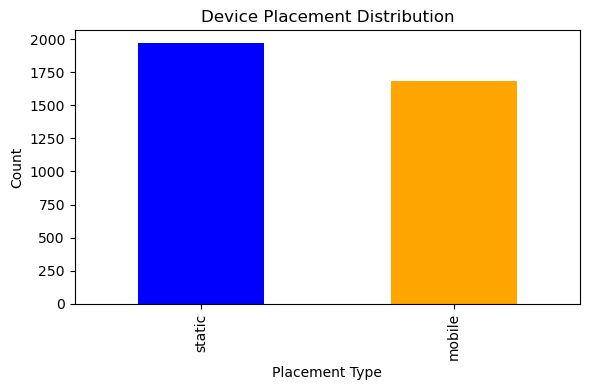

In [5]:
#-------------------------3a-------------------------
# Load metadata
metadata = pd.read_csv('C:/Users/rayan/Downloads/MLPC2026_dataset_development/metadata.csv')

print("=== Device Placement ===")
print(metadata['device_placement'].value_counts())
print()

print("=== Recording Devices ===")
print(metadata['recording_device'].value_counts().head(10))
print()

# Split and count environments
all_envs = []
for envs in metadata['recording_environment'].dropna():
    all_envs.extend(str(envs).split(';'))

from collections import Counter
env_counts = Counter(all_envs)
print("=== Recording Environments ===")
for env, count in env_counts.most_common():
    print(f"  {env}: {count}")

# Plot device placement
plt.figure(figsize=(6, 4))
metadata['device_placement'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Device Placement Distribution')
plt.xlabel('Placement Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
#-------------------------3b-------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your dataset
dataset_path = Path('C:/Users/rayan/Downloads/MLPC2026_dataset_development')
npz_files = list((dataset_path / 'audio_features').glob('*.npz'))
print(f"Found {len(npz_files)} files")

# Question 3b - Feature Statistics using ALL files
print("=" * 60)
print("Question 3b: Feature Statistics (ALL 3,656 Files)")
print("=" * 60)
print()

# Store statistics for each feature across all files
all_mfcc_mean = []
all_mfcc_std = []
all_zcr_mean = []
all_centroid_mean = []
all_bandwidth_mean = []
all_flatness_mean = []
all_rolloff_low_mean = []
all_rolloff_high_mean = []

for npz_path in npz_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        
        # MFCC
        if 'mfcc_mean' in data:
            all_mfcc_mean.append(data['mfcc_mean'].mean())
            all_mfcc_std.append(data['mfcc_mean'].std())
        
        # Zero Crossing Rate
        if 'zcr_mean' in data:
            all_zcr_mean.append(data['zcr_mean'].mean())
        
        # Spectral Centroid
        if 'centroid_mean' in data:
            all_centroid_mean.append(data['centroid_mean'].mean())
        
        # Spectral Bandwidth
        if 'bandwidth_mean' in data:
            all_bandwidth_mean.append(data['bandwidth_mean'].mean())
        
        # Spectral Flatness
        if 'flatness_mean' in data:
            all_flatness_mean.append(data['flatness_mean'].mean())
        
        # Low Rolloff
        if 'rolloff_low_mean' in data:
            all_rolloff_low_mean.append(data['rolloff_low_mean'].mean())
        
        # High Rolloff
        if 'rolloff_high_mean' in data:
            all_rolloff_high_mean.append(data['rolloff_high_mean'].mean())
            
    except Exception as e:
        continue

# Print results
print("FEATURE STATISTICS ACROSS ALL 3,656 FILES")
print("-" * 40)
print()

if len(all_mfcc_mean) > 0:
    print(f"MFCC (Mel-frequency cepstral coefficients):")
    print(f"  Mean of means: {np.mean(all_mfcc_mean):.4f}")
    print(f"  Std of means:  {np.std(all_mfcc_mean):.4f}")
    print(f"  Min across files: {np.min(all_mfcc_mean):.4f}")
    print(f"  Max across files: {np.max(all_mfcc_mean):.4f}")
    print(f"  Range: {np.max(all_mfcc_mean) - np.min(all_mfcc_mean):.4f}")
    print()

if len(all_zcr_mean) > 0:
    print(f"Zero Crossing Rate (ZCR):")
    print(f"  Mean: {np.mean(all_zcr_mean):.4f}")
    print(f"  Std:  {np.std(all_zcr_mean):.4f}")
    print(f"  Min:  {np.min(all_zcr_mean):.4f}")
    print(f"  Max:  {np.max(all_zcr_mean):.4f}")
    print(f"  Range: {np.max(all_zcr_mean) - np.min(all_zcr_mean):.4f}")
    print()

if len(all_centroid_mean) > 0:
    print(f"Spectral Centroid (Hz):")
    print(f"  Mean: {np.mean(all_centroid_mean):.4f}")
    print(f"  Std:  {np.std(all_centroid_mean):.4f}")
    print(f"  Min:  {np.min(all_centroid_mean):.4f}")
    print(f"  Max:  {np.max(all_centroid_mean):.4f}")
    print(f"  Range: {np.max(all_centroid_mean) - np.min(all_centroid_mean):.4f}")
    print()

if len(all_bandwidth_mean) > 0:
    print(f"Spectral Bandwidth (Hz):")
    print(f"  Mean: {np.mean(all_bandwidth_mean):.4f}")
    print(f"  Std:  {np.std(all_bandwidth_mean):.4f}")
    print(f"  Min:  {np.min(all_bandwidth_mean):.4f}")
    print(f"  Max:  {np.max(all_bandwidth_mean):.4f}")
    print(f"  Range: {np.max(all_bandwidth_mean) - np.min(all_bandwidth_mean):.4f}")
    print()

if len(all_flatness_mean) > 0:
    print(f"Spectral Flatness:")
    print(f"  Mean: {np.mean(all_flatness_mean):.4f}")
    print(f"  Std:  {np.std(all_flatness_mean):.4f}")
    print(f"  Min:  {np.min(all_flatness_mean):.4f}")
    print(f"  Max:  {np.max(all_flatness_mean):.4f}")
    print(f"  Range: {np.max(all_flatness_mean) - np.min(all_flatness_mean):.4f}")
    print()

if len(all_rolloff_low_mean) > 0:
    print(f"Low Rolloff (Hz):")
    print(f"  Mean: {np.mean(all_rolloff_low_mean):.4f}")
    print(f"  Std:  {np.std(all_rolloff_low_mean):.4f}")
    print(f"  Min:  {np.min(all_rolloff_low_mean):.4f}")
    print(f"  Max:  {np.max(all_rolloff_low_mean):.4f}")
    print(f"  Range: {np.max(all_rolloff_low_mean) - np.min(all_rolloff_low_mean):.4f}")
    print()

if len(all_rolloff_high_mean) > 0:
    print(f"High Rolloff (Hz):")
    print(f"  Mean: {np.mean(all_rolloff_high_mean):.4f}")
    print(f"  Std:  {np.std(all_rolloff_high_mean):.4f}")
    print(f"  Min:  {np.min(all_rolloff_high_mean):.4f}")
    print(f"  Max:  {np.max(all_rolloff_high_mean):.4f}")
    print(f"  Range: {np.max(all_rolloff_high_mean) - np.min(all_rolloff_high_mean):.4f}")
    print()

print(f"Successfully processed {len(all_mfcc_mean)} files")

Found 3656 files
Question 3b: Feature Statistics (ALL 3,656 Files)

FEATURE STATISTICS ACROSS ALL 3,656 FILES
----------------------------------------

MFCC (Mel-frequency cepstral coefficients):
  Mean of means: -2.0511
  Std of means:  0.3915
  Min across files: -4.0661
  Max across files: -0.6293
  Range: 3.4368

Zero Crossing Rate (ZCR):
  Mean: 0.1917
  Std:  0.0929
  Min:  0.0041
  Max:  0.6007
  Range: 0.5966

Spectral Centroid (Hz):
  Mean: 2208.3603
  Std:  632.6167
  Min:  32.1696
  Max:  4769.6821
  Range: 4737.5125

Spectral Bandwidth (Hz):
  Mean: 2785.4261
  Std:  377.6759
  Min:  48.4374
  Max:  3787.0073
  Range: 3738.5699

Spectral Flatness:
  Mean: 0.0881
  Std:  0.0616
  Min:  0.0001
  Max:  0.9884
  Range: 0.9882

Low Rolloff (Hz):
  Mean: 300.5056
  Std:  210.1282
  Min:  2.3181
  Max:  2011.5918
  Range: 2009.2737

High Rolloff (Hz):
  Mean: 5074.2853
  Std:  960.2276
  Min:  86.1194
  Max:  7179.1159
  Range: 7092.9965

Successfully processed 3656 files


Question 3c: Feature Correlation (ALL 3,656 Files)

Files with complete feature data: 3656 out of 3656

CORRELATION MATRIX:
----------------------------------------
                   mfcc_mean  zcr_mean  centroid_mean  bandwidth_mean  \
mfcc_mean           1.000000 -0.037668      -0.007244        0.040696   
zcr_mean           -0.037668  1.000000       0.960059        0.662769   
centroid_mean      -0.007244  0.960059       1.000000        0.821221   
bandwidth_mean      0.040696  0.662769       0.821221        1.000000   
flatness_mean      -0.056210  0.730623       0.728702        0.522793   
rolloff_low_mean   -0.107091  0.863128       0.792726        0.386163   
rolloff_high_mean   0.014142  0.784912       0.912177        0.967184   

                   flatness_mean  rolloff_low_mean  rolloff_high_mean  
mfcc_mean              -0.056210         -0.107091           0.014142  
zcr_mean                0.730623          0.863128           0.784912  
centroid_mean           0.728702  

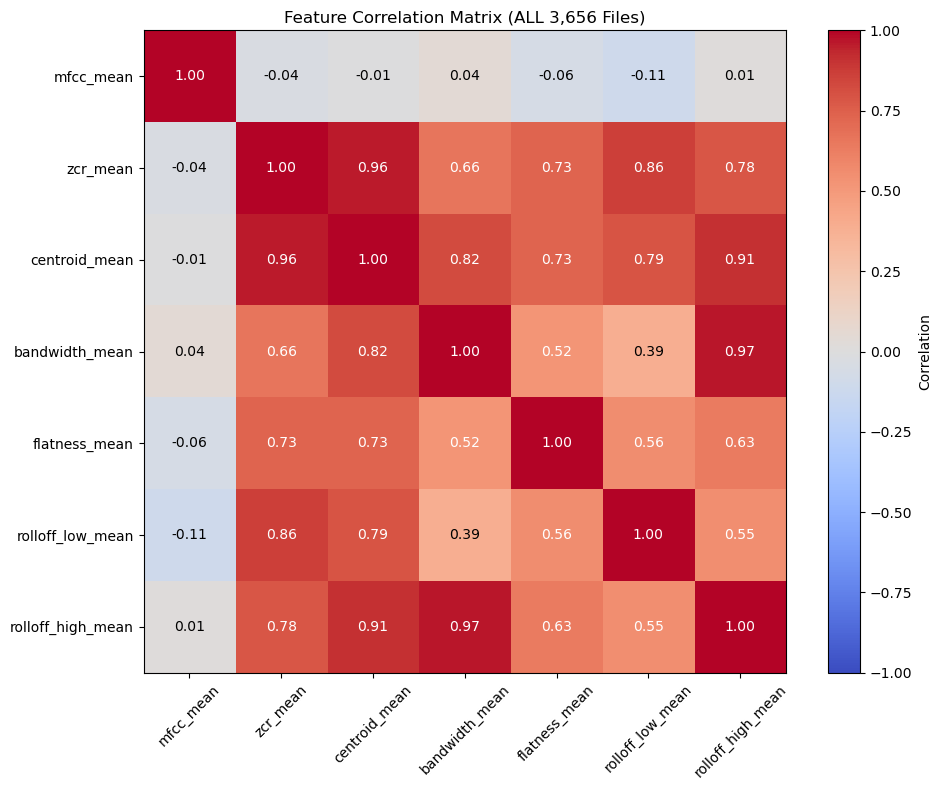


STRONGEST CORRELATIONS:
----------------------------------------
zcr_mean vs centroid_mean: 0.96
zcr_mean vs bandwidth_mean: 0.66
zcr_mean vs flatness_mean: 0.73
zcr_mean vs rolloff_low_mean: 0.86
zcr_mean vs rolloff_high_mean: 0.78
centroid_mean vs bandwidth_mean: 0.82
centroid_mean vs flatness_mean: 0.73
centroid_mean vs rolloff_low_mean: 0.79
centroid_mean vs rolloff_high_mean: 0.91
bandwidth_mean vs flatness_mean: 0.52
bandwidth_mean vs rolloff_high_mean: 0.97
flatness_mean vs rolloff_low_mean: 0.56
flatness_mean vs rolloff_high_mean: 0.63
rolloff_low_mean vs rolloff_high_mean: 0.55


In [7]:
# Question 3c - Feature Correlation using ALL files
print("=" * 60)
print("Question 3c: Feature Correlation (ALL 3,656 Files)")
print("=" * 60)
print()

# Store feature vectors for all files
all_feature_vectors = []

for npz_path in npz_files:
    try:
        data = np.load(npz_path, allow_pickle=True)
        
        # Create a feature vector for this file
        feature_vector = []
        
        # Add each feature (mean across time for the file)
        if 'mfcc_mean' in data:
            feature_vector.append(data['mfcc_mean'].mean())
        else:
            feature_vector.append(np.nan)
            
        if 'zcr_mean' in data:
            feature_vector.append(data['zcr_mean'].mean())
        else:
            feature_vector.append(np.nan)
            
        if 'centroid_mean' in data:
            feature_vector.append(data['centroid_mean'].mean())
        else:
            feature_vector.append(np.nan)
            
        if 'bandwidth_mean' in data:
            feature_vector.append(data['bandwidth_mean'].mean())
        else:
            feature_vector.append(np.nan)
            
        if 'flatness_mean' in data:
            feature_vector.append(data['flatness_mean'].mean())
        else:
            feature_vector.append(np.nan)
            
        if 'rolloff_low_mean' in data:
            feature_vector.append(data['rolloff_low_mean'].mean())
        else:
            feature_vector.append(np.nan)
            
        if 'rolloff_high_mean' in data:
            feature_vector.append(data['rolloff_high_mean'].mean())
        else:
            feature_vector.append(np.nan)
        
        all_feature_vectors.append(feature_vector)
        
    except Exception as e:
        continue

# Convert to DataFrame
feature_names = ['mfcc_mean', 'zcr_mean', 'centroid_mean', 'bandwidth_mean', 
                 'flatness_mean', 'rolloff_low_mean', 'rolloff_high_mean']

df_features = pd.DataFrame(all_feature_vectors, columns=feature_names)

# Remove rows with NaN
df_features = df_features.dropna()

print(f"Files with complete feature data: {len(df_features)} out of {len(npz_files)}")
print()

# Calculate correlation matrix
correlation_matrix = df_features.corr()

print("CORRELATION MATRIX:")
print("-" * 40)
print(correlation_matrix)
print()

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.yticks(range(len(feature_names)), feature_names)
plt.title('Feature Correlation Matrix (ALL 3,656 Files)')

# Add correlation values inside the plot
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', 
                 color='white' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

# Print strongest correlations
print()
print("STRONGEST CORRELATIONS:")
print("-" * 40)
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            print(f"{feature_names[i]} vs {feature_names[j]}: {corr:.2f}")

In [8]:
# Question 3d (Bonus) - PCA Visualization
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use the features we already have
feature_matrix = np.column_stack([features_dict[f] for f in features_dict.keys()])
feature_names = list(features_dict.keys())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA Visualization of Audio Feature Space')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")

NameError: name 'features_dict' is not defined